In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
import os
import pandas as pd

In [23]:
import src.config as cfg
import src.data_loader as loader
import src.analysis as analysis
import src.visualization as viz

In [24]:

taxonomy_map = loader.load_taxonomy_mapping(cfg.TAXONOMY_CSV)
snapshots, df_index, df_issues = loader.build_yearly_index(
    data_folder=cfg.DATA_FOLDER,
    start_year=cfg.START_YEAR,
    end_year=cfg.END_YEAR,
    taxonomy_map=taxonomy_map,
    level=cfg.LEVEL
)

Nivel taxonómico:  meso
[OK] 1980 | alters=26 | cats_unique=19 | missing_csv=0
[OK] 1981 | alters=63 | cats_unique=39 | missing_csv=0
[OK] 1982 | alters=58 | cats_unique=34 | missing_csv=0
[OK] 1983 | alters=35 | cats_unique=27 | missing_csv=0
[OK] 1984 | alters=45 | cats_unique=28 | missing_csv=0
[OK] 1985 | alters=33 | cats_unique=25 | missing_csv=0
[OK] 1986 | alters=18 | cats_unique=14 | missing_csv=0
[OK] 1987 | alters=286 | cats_unique=127 | missing_csv=0
[OK] 1988 | alters=128 | cats_unique=67 | missing_csv=0
[OK] 1989 | alters=61 | cats_unique=35 | missing_csv=0
[OK] 1990 | alters=85 | cats_unique=48 | missing_csv=1
[OK] 1991 | alters=244 | cats_unique=107 | missing_csv=0
[OK] 1992 | alters=224 | cats_unique=114 | missing_csv=0
[OK] 1993 | alters=103 | cats_unique=55 | missing_csv=0
[OK] 1994 | alters=63 | cats_unique=41 | missing_csv=0
[OK] 1995 | alters=167 | cats_unique=91 | missing_csv=0
[OK] 1996 | alters=595 | cats_unique=210 | missing_csv=0
[OK] 1997 | alters=150 | cats_

In [25]:
print("\n--- Resumen (df_index) ---")
print(df_index)

print("\n--- Issues/Warns (df_issues) ---")
print(df_issues.head())

print(f"\nAños procesados correctamente: {len(snapshots)} / {cfg.END_YEAR - cfg.START_YEAR + 1}")


--- Resumen (df_index) ---
    year         ego_id  n_items_total  n_links_total  n_alters  n_features  \
0   1980  MCT.4.61.1335             27             26        26           8   
1   1981  MCT.4.61.1335             64             63        63           8   
2   1982  MCT.4.61.1335             59             58        58           8   
3   1983  MCT.4.61.1335             36             35        35           8   
4   1984  MCT.4.61.1335             46             45        45           8   
5   1985  MCT.4.61.1335             34             33        33           8   
6   1986  MCT.4.61.1335             19             18        18           8   
7   1987  MCT.4.61.1335            287            286       286           8   
8   1988  MCT.4.61.1335            129            128       128           8   
9   1989  MCT.4.61.1335             62             61        61           8   
10  1990  MCT.4.61.1335             86             85        85           8   
11  1991  MCT.4.61.1335 

In [26]:
feature_names = [k for (_, k) in cfg.FEATURES]
df_stage2 = analysis.run_stage2(
    snapshots=snapshots,
    feature_names=feature_names,
    documents_col_name="Documents,"
)
out_path = f"./Output/metricas_{cfg.LEVEL}.csv"
df_stage2.to_csv(out_path, index=False)
print(f"\n[OK] Guardado: {out_path}")



[OK] Guardado: ./Output/metricas_meso.csv


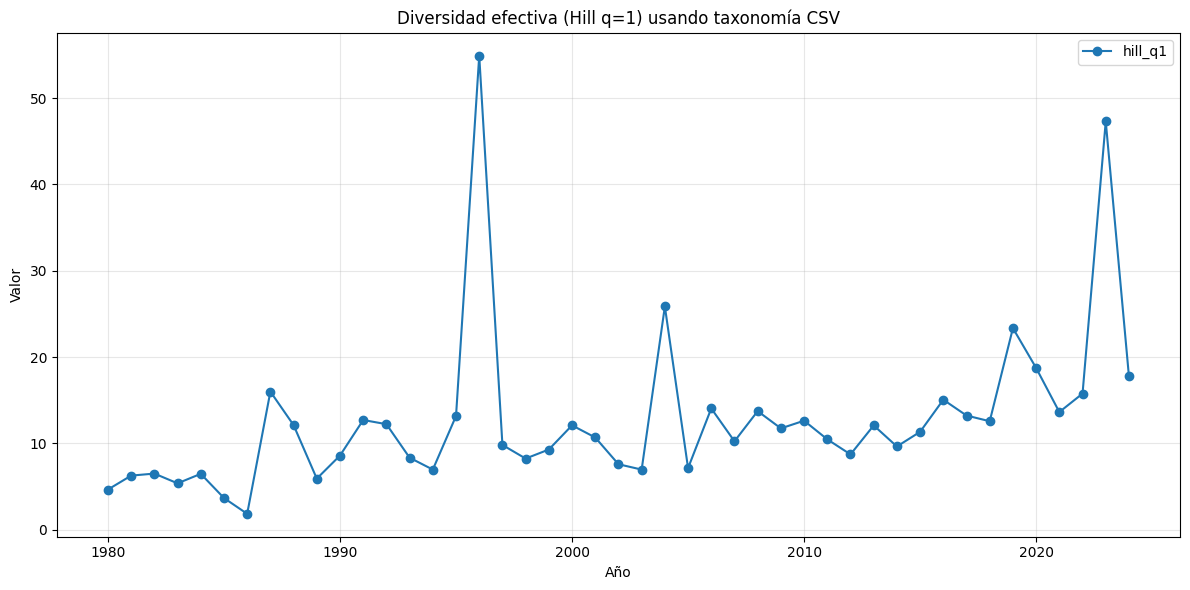

In [27]:
df = df_stage2.copy()
# diversidad efectiva (q=1)
viz.plot_timeseries_matplotlib(
    df,
    cols=["hill_q1"],
    title="Diversidad efectiva (Hill q=1) usando taxonomía CSV"
)


#Sobre clusters:
#“¿Cuántos grupos hay en el vecindario del ego este año?”
#“¿Está dominado por un solo grupo o está balanceado?”

#En la siguiente gráfica un pico alto significa que la masa (en este caso documentos) está más repartida entre varios clusters
#Un pico bajo significa que la masa está concentrada en pocos clusters.
#en 1996 la masa es mas diversa, la mayor concentracion está en unos 5 clusters
# en 1980 la masa está mas condensada en 2 clusters

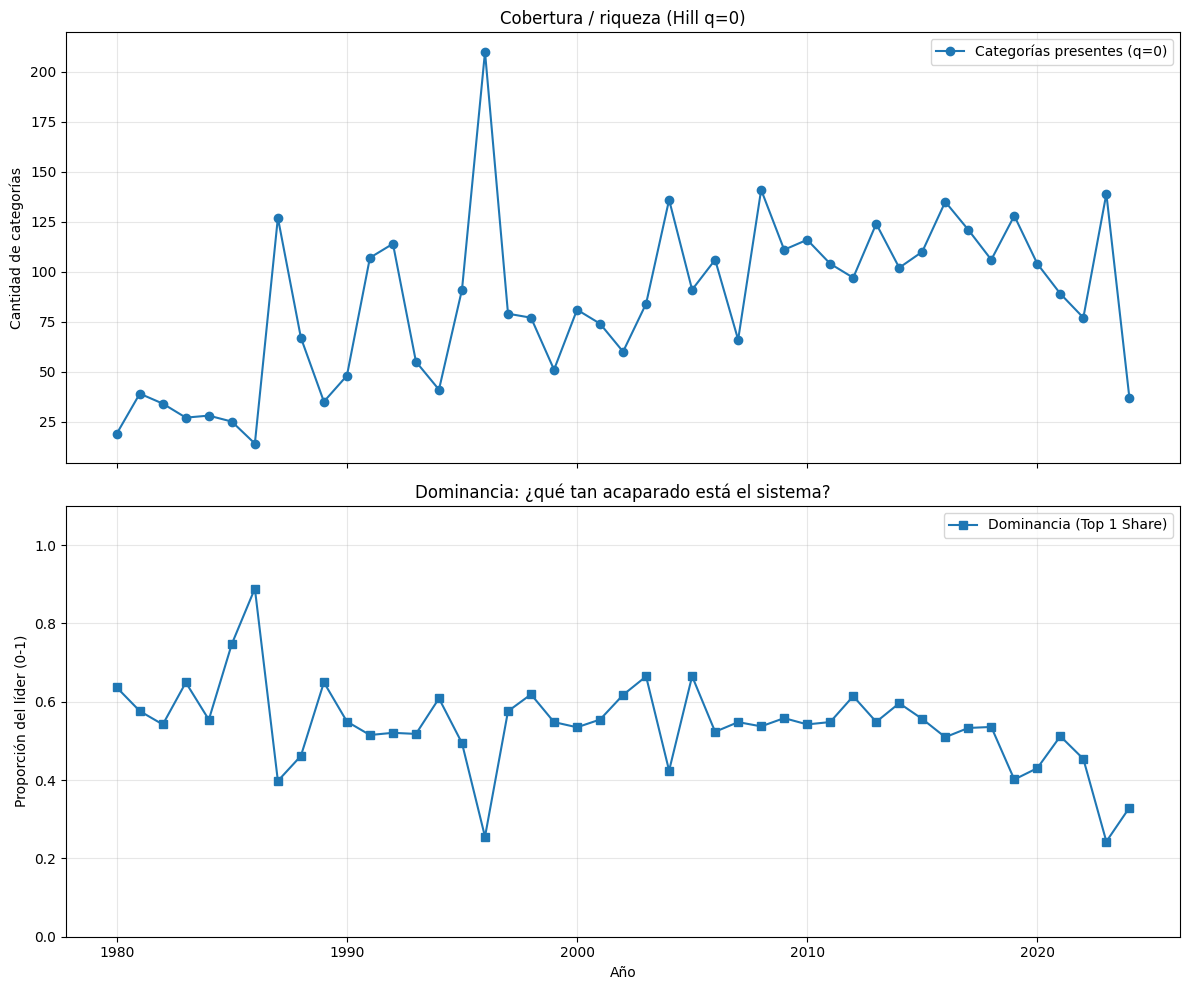

In [28]:
viz.plot_separated_metrics(df)
#EL top 1 share (masa) indica qué proporcion de la masa total está acaparada por el cluster más grande.
#Ej: si el valor es 0.90, entonces el 90% de la producción proviene de un único cluster

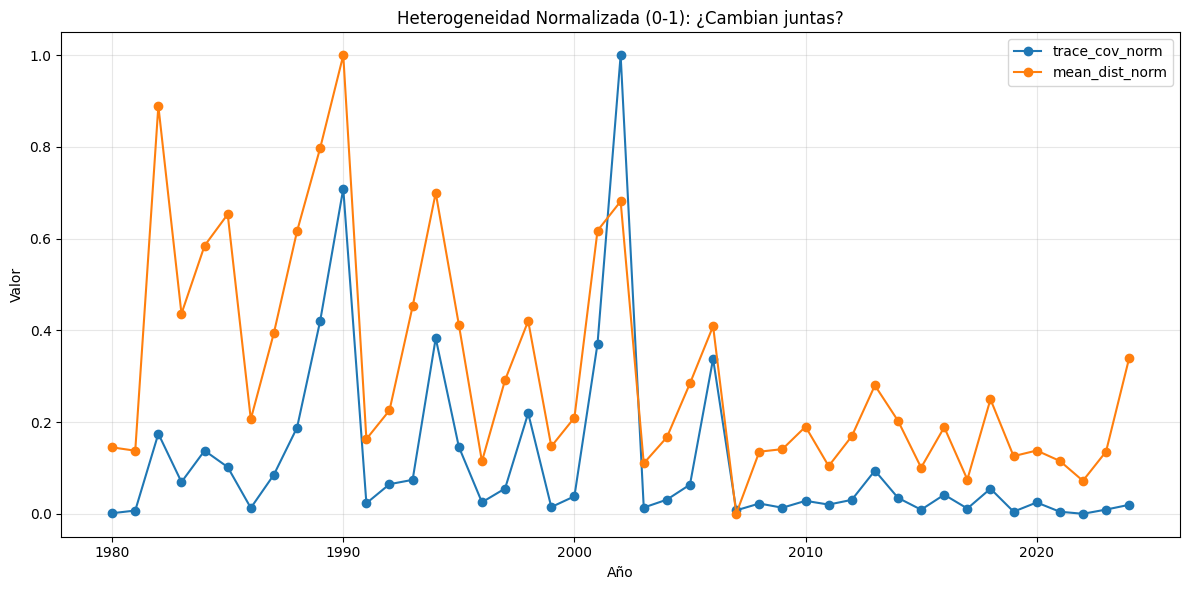

In [29]:
# Aplicamos la normalización (minmax) para que ambas vivan entre 0 y 1
df_norm = df.copy()
df_norm["trace_cov_norm"] = viz.minmax_01(df["trace_cov"])
df_norm["mean_dist_norm"] = viz.minmax_01(df["mean_dist_to_mu"])

viz.plot_timeseries_matplotlib(
    df_norm,
    cols=["trace_cov_norm", "mean_dist_norm"],
    title="Heterogeneidad Normalizada (0-1): ¿Cambian juntas?"
)

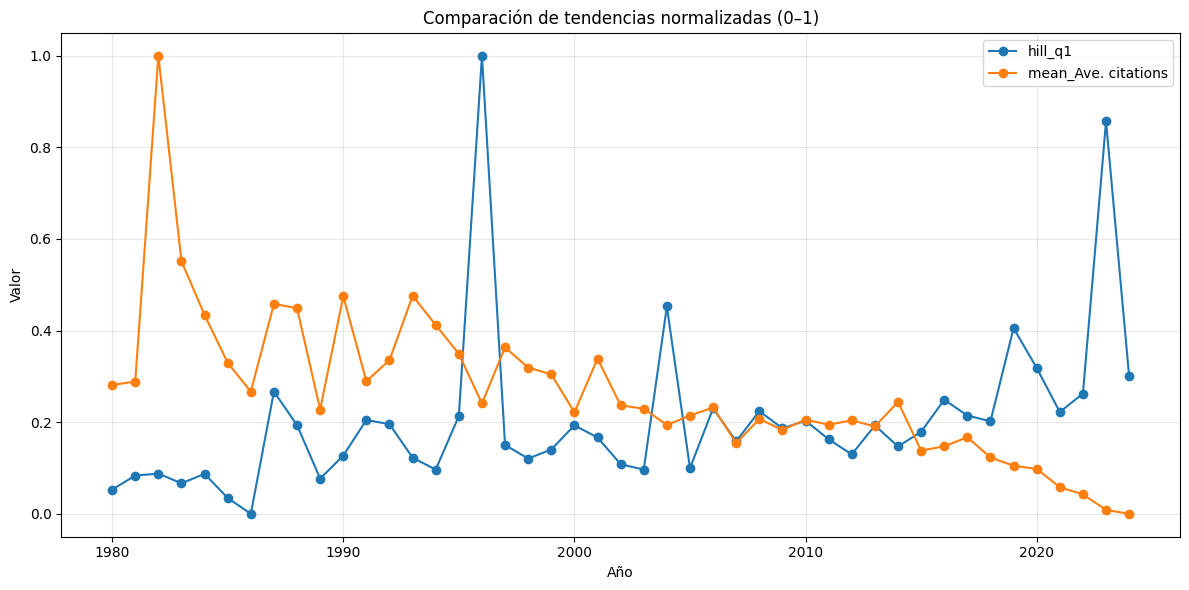

In [30]:
df_cmp = pd.DataFrame({"year": df["year"]})
to_compare = [
    "hill_q1",
   # "hill_strength_q1",
   # "mean_Ave. authorships",
    "mean_Ave. citations",
   # "top1_share_docs"
]

for c in to_compare:
    if c in df.columns:
        df_cmp[c] = viz.minmax_01(df[c])

viz.plot_timeseries_matplotlib(
    df_cmp,
    cols=[c for c in to_compare if c in df_cmp.columns],
    title="Comparación de tendencias normalizadas (0–1)"
)

#"Cuando el ego diversifica sus temas, tiende a colaborar con gente de mayor impacto" (hill vs documents)

In [31]:
# Correlacion de pearson
metrics_core = [
    "hill_q1", "hill_q2",
    "top1_share",
    "trace_cov", "mean_dist_to_mu",
    "mean_Ave. authorships", "mean_Ave. citations", "mean_Ave. references",
    "mean_Percent of documents", "mean_Percent of documents Int. Coll."
]

metrics_core = [c for c in metrics_core if c in df.columns]

df_metrics = df[metrics_core].copy()

corr_pearson = df_metrics.corr(method="pearson")
corr_spearman = df_metrics.corr(method="spearman")

print("\n--- Correlación Pearson (métricas core) ---")
print(corr_pearson.round(3))

print("\n--- Correlación Spearman (métricas core) ---")
print(corr_spearman.round(3))


--- Correlación Pearson (métricas core) ---
                                      hill_q1  hill_q2  top1_share  trace_cov  \
hill_q1                                 1.000    0.963      -0.826     -0.208   
hill_q2                                 0.963    1.000      -0.856     -0.185   
top1_share                             -0.826   -0.856       1.000      0.173   
trace_cov                              -0.208   -0.185       0.173      1.000   
mean_dist_to_mu                        -0.326   -0.229       0.215      0.752   
mean_Ave. authorships                   0.517    0.477      -0.558     -0.340   
mean_Ave. citations                    -0.358   -0.293       0.250      0.272   
mean_Ave. references                   -0.098    0.005      -0.046      0.635   
mean_Percent of documents              -0.450   -0.360       0.636      0.046   
mean_Percent of documents Int. Coll.    0.339    0.368      -0.346     -0.288   

                                      mean_dist_to_mu  mean_Ave

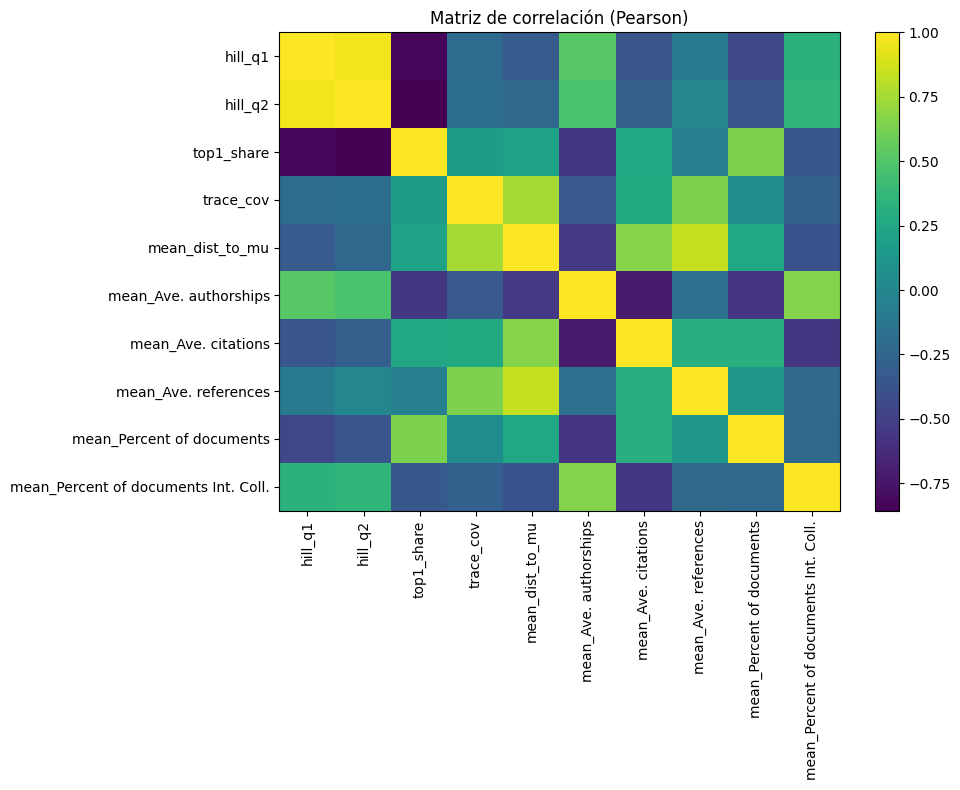

In [32]:
viz.plot_corr_matrix(corr_pearson, "Matriz de correlación (Pearson)")

In [33]:
feature_names = [k for (_, k) in cfg.FEATURES]
idx_docs = feature_names.index(cfg.DOCS_COL) if cfg.DOCS_COL in feature_names else None #Solo es para ubicar la posicion del feature "Documents,"


In [34]:
global_edges = analysis.compute_global_thresholds(snapshots, feature_names, cfg.CAT_SPECS)

[OK] Ave. citations: edges globales = [ 2.77   9.    22.045]
[OK] Ave. references: edges globales = [31. 46. 73.]
[OK] Percent of documents Int. Coll.: edges globales = [ 0. 25.]
[OK] Ave. authorships: edges globales = [3.   4.02]


In [35]:
df_cats = analysis.generate_anual_proportions(snapshots, feature_names, cfg.CAT_SPECS, global_edges, idx_docs)

In [36]:
# df_cats = pd.DataFrame(rows_cat).sort_values("year").reset_index(drop=True)

out_path_cats = f"./Output/categorias_{cfg.LEVEL}_detallado.csv"
df_cats.to_csv(out_path_cats, index=False)
print(f"[OK] Guardado categorías: {out_path_cats}")


[OK] Guardado categorías: ./Output/categorias_meso_detallado.csv


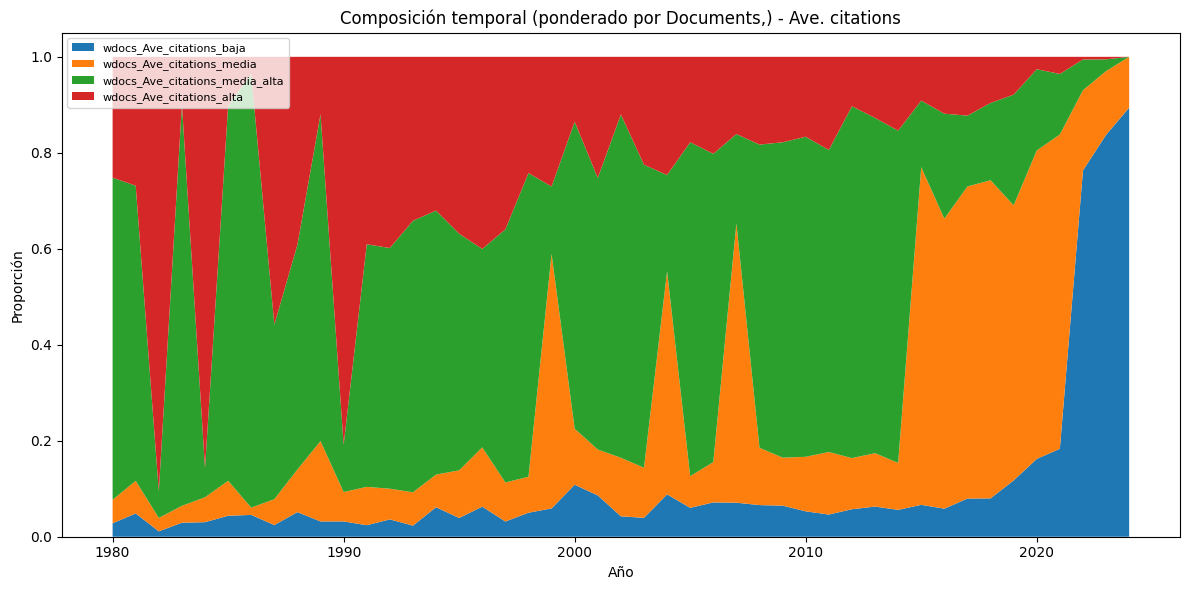

In [37]:
df_plot =df_cats


#feat = "Ave._authorships"
#feat = "Percent of documents Int. Coll."
feat = "Ave._citations"
#feat = "Ave._references"
safe_cit = feat.replace(" ", "_").replace(".", "").replace(",", "").replace("%", "pct")
cols_cit_w = [c for c in df_cats.columns if c.startswith(f"wdocs_{safe_cit}_")]
if len(cols_cit_w) > 0:
    viz.plot_stack_shares(
        df_plot,
        year_col="year",
        cols=cols_cit_w,
        title="Composición temporal (ponderado por Documents,) - Ave. citations"
    )

In [38]:
df = df_cats.copy()

#Lo unico que hace es extraer los "labels" definidos en la constante CAT_SPECS de config.py
specs_limpios = {}
for llave_sucia, valores in cfg.CAT_SPECS.items():
    llave_limpia = llave_sucia.replace(".", "").replace(" ", "_")
    specs_limpios[llave_limpia] = {"cats": valores["labels"]}

df2 = analysis.add_dominants(df, specs_limpios)

# Etiquetas en forma de palabras
label_cols = ["year"]
for feature in specs_limpios.keys():
    label_cols += [f"unw_{feature}", f"wdocs_{feature}"]

df_labels = df2[label_cols].sort_values("year").reset_index(drop=True)

#Etiquetas en forma de numeros
value_cols = ["year"]
for feature in specs_limpios.keys():
    value_cols += [f"unw_{feature}_value", f"wdocs_{feature}_value"]

df_values = df2[value_cols].sort_values("year").reset_index(drop=True)


In [39]:
out_dir = "./Output"
os.makedirs(out_dir, exist_ok=True)

out_path_labels = os.path.join(out_dir, f"categorias_{cfg.LEVEL}_simplificado_etiquetas.csv")
out_path_values = os.path.join(out_dir, f"categorias_{cfg.LEVEL}_simplificado_valores.csv")

df_labels.to_csv(out_path_labels, index=False, encoding="utf-8")
df_values.to_csv(out_path_values, index=False, encoding="utf-8")

print(f"[OK] Guardado etiquetas: {out_path_labels}")
print(f"[OK] Guardado valores (max share): {out_path_values}")

print("\n--- Preview etiquetas ---")
print(df_labels.head())

print("\n--- Preview valores ---")
print(df_values.head())

[OK] Guardado etiquetas: ./Output/categorias_meso_simplificado_etiquetas.csv
[OK] Guardado valores (max share): ./Output/categorias_meso_simplificado_valores.csv

--- Preview etiquetas ---
   year unw_Ave_citations wdocs_Ave_citations unw_Ave_references  \
0  1980              alta          media_alta               alta   
1  1981              alta          media_alta              media   
2  1982              alta                alta               alta   
3  1983        media_alta          media_alta               baja   
4  1984              alta                alta               alta   

  wdocs_Ave_references unw_Percent_of_documents_Int_Coll  \
0                media                              baja   
1                media                              baja   
2                media                              baja   
3                media                              baja   
4                media                              baja   

  wdocs_Percent_of_documents_Int_Coll unw